In [7]:
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("../data/raw/creditcard.csv")

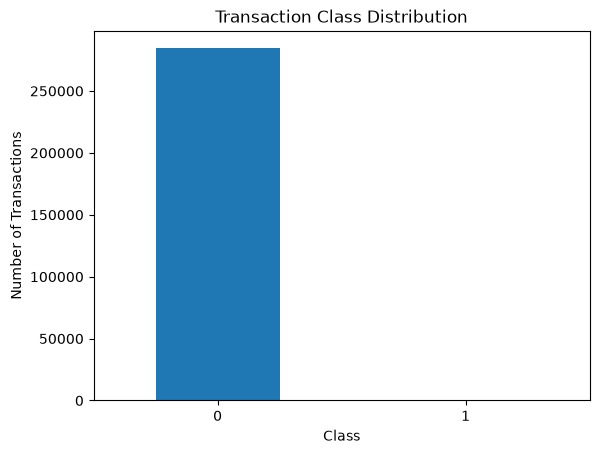

In [11]:
import matplotlib.pyplot as plt
df["Class"].value_counts().plot(kind="bar")

plt.title("Transaction Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

In [12]:
class_counts = df["Class"].value_counts()
class_counts

Class
0    284315
1       492
Name: count, dtype: int64

In [13]:
class_percentages = df["Class"].value_counts(normalize=True) * 100
class_percentages

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [14]:
print("Legitimate transactions:", class_counts[0])
print("Fraud transactions:", class_counts[1])
print("Legitimate percentage:", round(class_percentages[0], 4), "%")
print("Fraud percentage:", round(class_percentages[1], 4), "%")

Legitimate transactions: 284315
Fraud transactions: 492
Legitimate percentage: 99.8273 %
Fraud percentage: 0.1727 %


In [15]:
df["Time"].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

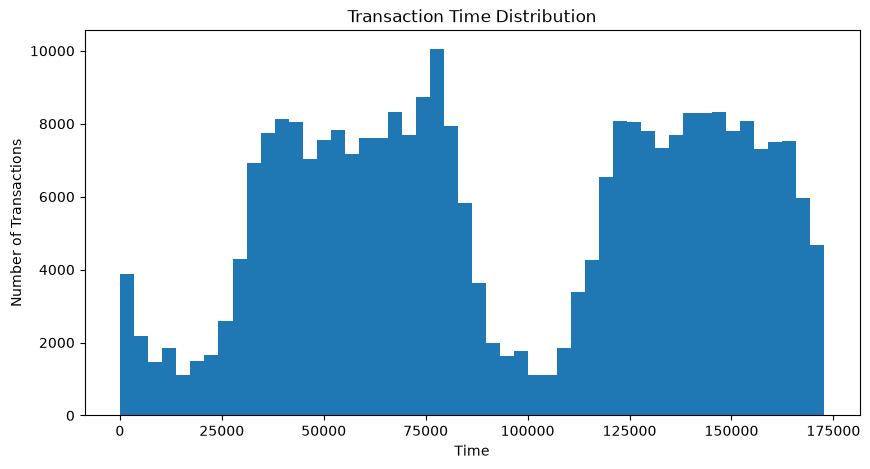

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(df["Time"], bins=50)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

In [17]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

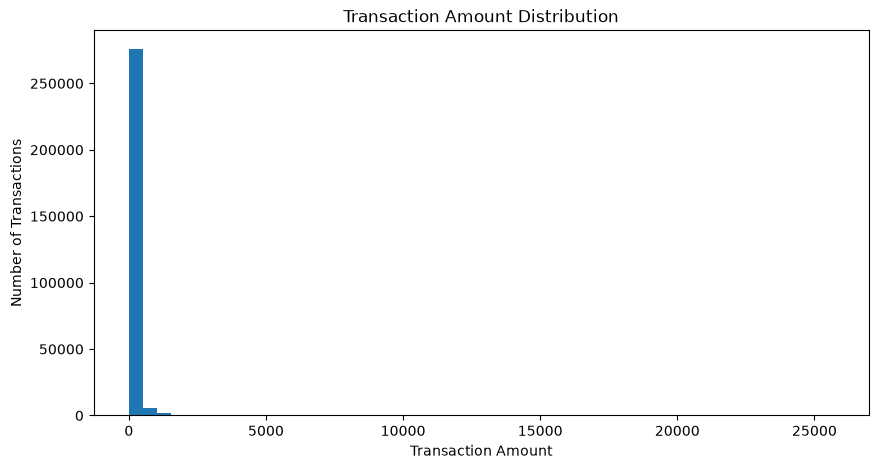

In [18]:
plt.figure(figsize=(10, 5))

plt.hist(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

In [20]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


<Figure size 800x500 with 0 Axes>

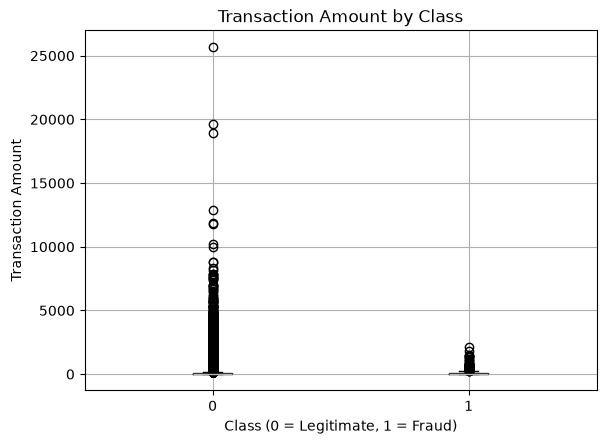

In [21]:
plt.figure(figsize=(8, 5))

df.boxplot(column="Amount", by="Class")

plt.title("Transaction Amount by Class")
plt.suptitle("")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

In [22]:
df.groupby("Class")["Amount"].median()

Class
0    22.00
1     9.25
Name: Amount, dtype: float64

In [23]:
df.groupby("Class")["Amount"].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

In [24]:
v_features = [f"V{i}" for i in range(1, 29)]

v_features

['V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28']

In [25]:
df[v_features].describe().T

,count,mean,std,min,25%,50%,75%,max
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995
V10,284807.0,2.238554e-15,1.088850,-24.588262,-0.535426,-0.092917,0.453923,23.745136


In [26]:
df.groupby("Class")[v_features].mean().T

Class,0,1
V1,0.008258,-4.771948
V2,-0.006271,3.623778
V3,0.012171,-7.033281
V4,-0.007860,4.542029
V5,0.005453,-3.151225
V6,0.002419,-1.397737
V7,0.009637,-5.568731
V8,-0.000987,0.570636
V9,0.004467,-2.581123
V10,0.009824,-5.676883


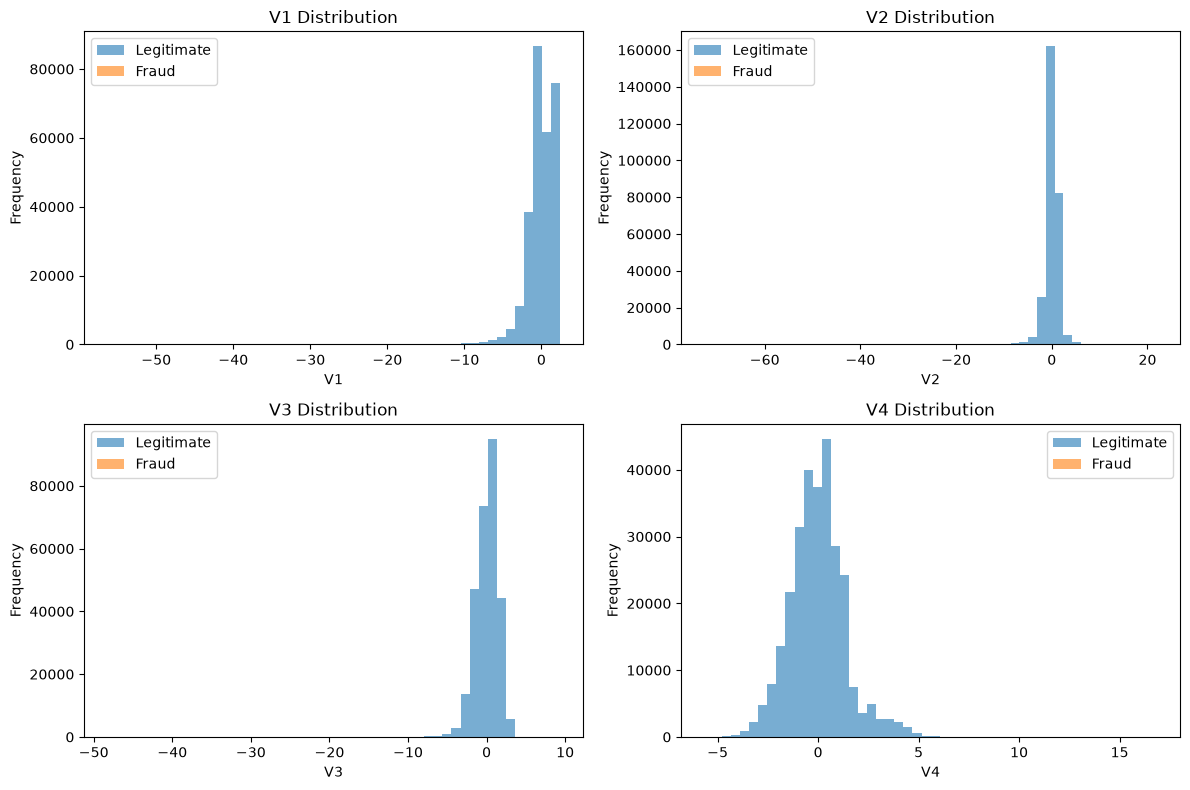

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.ravel(), v_features[:4]):
    ax.hist(df[df["Class"] == 0][feature], bins=50, alpha=0.6, label="Legitimate")
    ax.hist(df[df["Class"] == 1][feature], bins=50, alpha=0.6, label="Fraud")
    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

In [28]:
correlation_matrix = df.corr()

In [29]:
class_correlation = correlation_matrix["Class"].sort_values()

class_correlation

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64

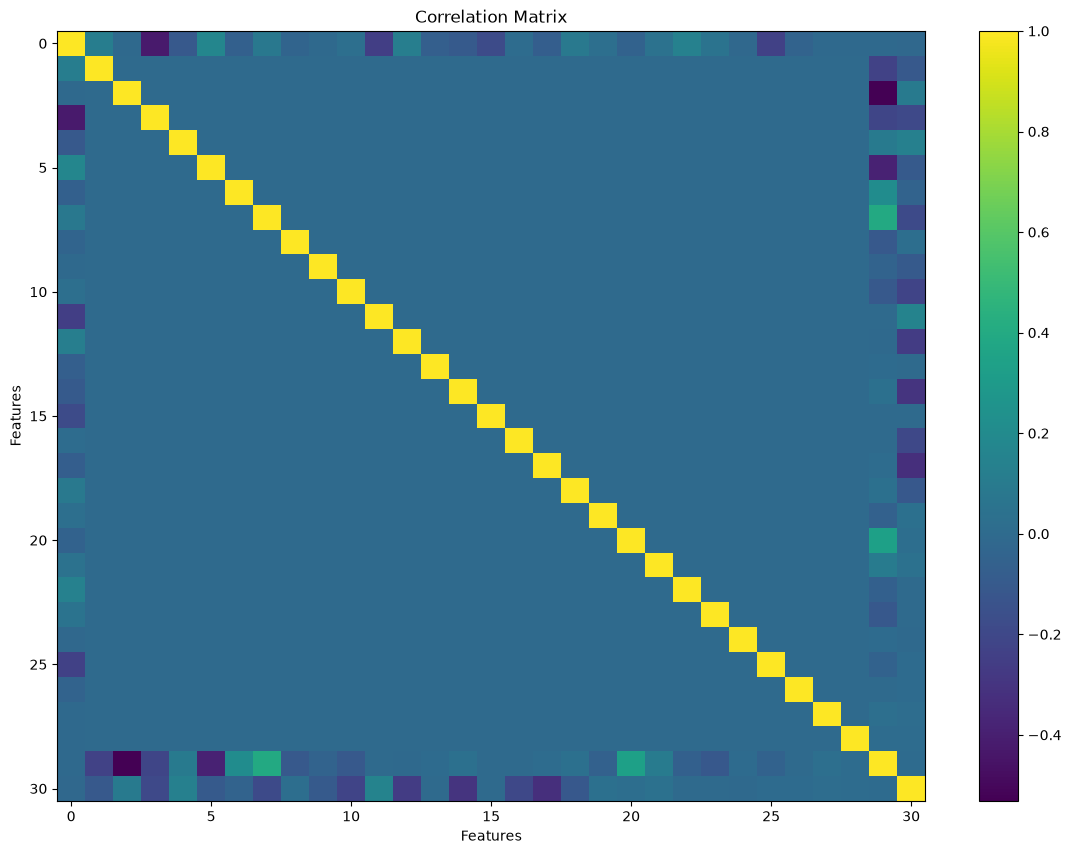

In [30]:
plt.figure(figsize=(14, 10))

plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()

plt.title("Correlation Matrix")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

In [31]:
class_corr_abs = correlation_matrix["Class"].drop("Class").abs().sort_values(ascending=False)

class_corr_abs.head(10)

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64

In [32]:
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 5.6
Q3: 77.16499999999999
IQR: 71.565
Lower Bound: -101.7475
Upper Bound: 184.5125


In [33]:
amount_outliers = df[
    (df["Amount"] < lower_bound) |
    (df["Amount"] > upper_bound)
]

print("Potential Amount outliers:", len(amount_outliers))

Potential Amount outliers: 31904


In [34]:
amount_outliers["Class"].value_counts()

Class
0    31813
1       91
Name: count, dtype: int64

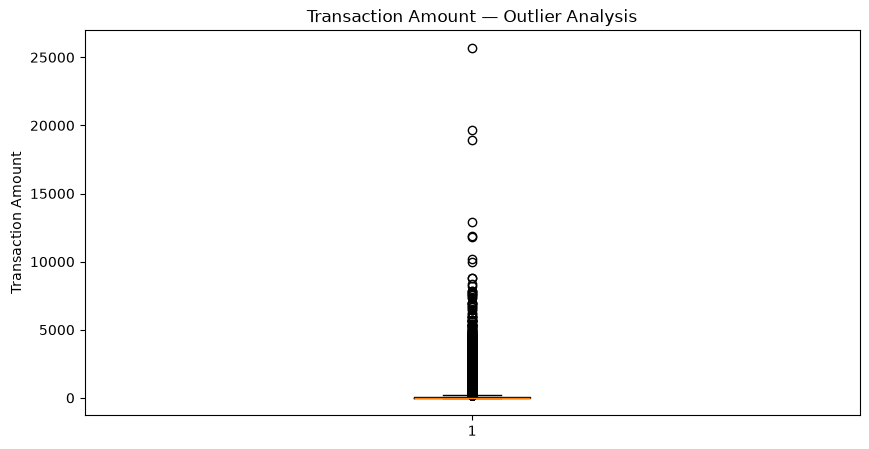

In [35]:
plt.figure(figsize=(10, 5))

plt.boxplot(df["Amount"])

plt.title("Transaction Amount — Outlier Analysis")
plt.ylabel("Transaction Amount")

plt.show()

In [36]:
zero_amount_count = (df["Amount"] == 0).sum()

print("Transactions with Amount = 0:", zero_amount_count)

Transactions with Amount = 0: 1825


## EDA Summary

### Key Findings

1. The dataset contains 284,807 transactions and 31 columns.
2. The target variable is `Class`, where 0 represents legitimate transactions and 1 represents fraud.
3. The dataset is highly imbalanced, with fraud transactions representing only about 0.17% of all transactions.
4. The `Time` feature represents elapsed time from the first transaction in the dataset.
5. The `Amount` feature has a skewed distribution with potential extreme values.
6. The `V1` to `V28` features are anonymized PCA-transformed numerical features.
7. Feature distributions and mean values differ between legitimate and fraudulent transactions for some features.
8. Correlation analysis shows that some features have stronger linear relationships with the fraud target than others.
9. Potential outliers exist in transaction amounts, but they should not automatically be removed because unusual transactions may contain useful fraud-related information.
10. There are no missing values in the dataset based on our initial inspection.